# Soil & Fertilizer Recommendation System

---
## Section 0 — Install Dependencies

In [1]:
!pip install shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# SMOTE for class imbalance
from imblearn.over_sampling import SMOTE

# SHAP
import shap

print('All libraries imported successfully.')
print(f'SHAP version: {shap.__version__}')

All libraries imported successfully.
SHAP version: 0.51.0


---
## Section 1 — Data Loading & Exploration

In [3]:
# ----- Mount Google Drive -----
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/CSE 710/AAI Project/Datasets/fertilizer_recommendation.csv')

print('Dataset shape:', df.shape)
df.head()

Mounted at /content/drive
Dataset shape: (10000, 20)


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


In [4]:
#print('=== Column Types ===')
#print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Class Distribution ===')
print(df['Recommended_Fertilizer'].value_counts())


=== Missing Values ===
Soil_Type                      0
Soil_pH                        0
Soil_Moisture                  0
Organic_Carbon                 0
Electrical_Conductivity        0
Nitrogen_Level                 0
Phosphorus_Level               0
Potassium_Level                0
Temperature                    0
Humidity                       0
Rainfall                       0
Crop_Type                      0
Crop_Growth_Stage              0
Season                         0
Irrigation_Type                0
Previous_Crop                  0
Region                         0
Fertilizer_Used_Last_Season    0
Yield_Last_Season              0
Recommended_Fertilizer         0
dtype: int64

=== Target Class Distribution ===
Recommended_Fertilizer
Urea             3101
DAP              2920
MOP              1408
Compost           996
Zinc Sulphate     752
NPK               641
SSP               182
Name: count, dtype: int64


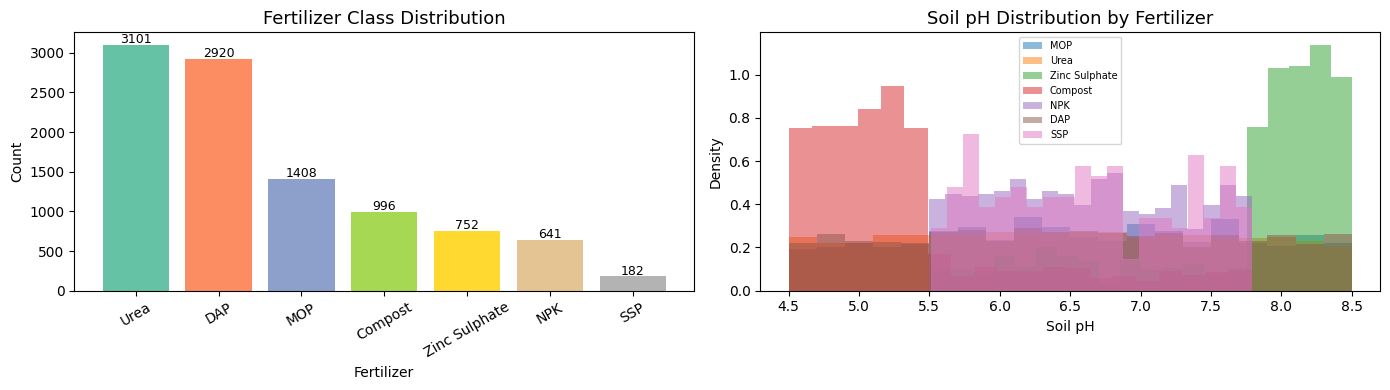

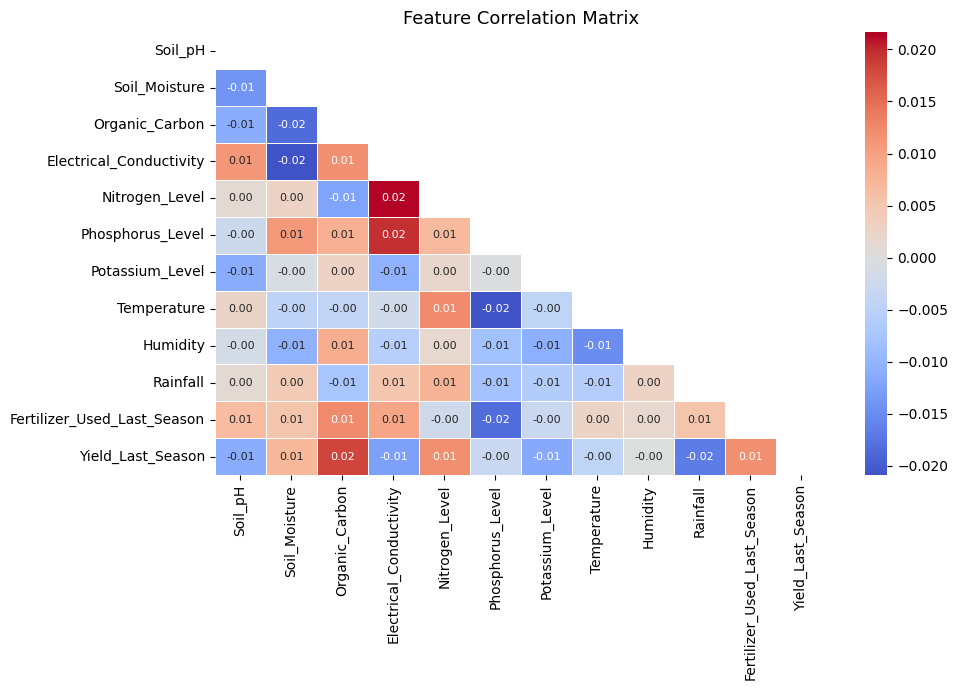

In [5]:
# Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution bar chart
counts = df['Recommended_Fertilizer'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(counts)))
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Fertilizer Class Distribution', fontsize=13)
axes[0].set_xlabel('Fertilizer')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

# Soil pH distribution by fertilizer
fertilizers = df['Recommended_Fertilizer'].unique()
for fert in fertilizers:
    subset = df[df['Recommended_Fertilizer'] == fert]['Soil_pH']
    axes[1].hist(subset, bins=20, alpha=0.5, label=fert, density=True)
axes[1].set_title('Soil pH Distribution by Fertilizer', fontsize=13)
axes[1].set_xlabel('Soil pH')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

# Correlation heatmap of numerical features
plt.figure(figsize=(10, 7))
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 2 — Preprocessing


In [6]:
df_proc = df.copy()

# ── 1. Label-encode categoricals ──────────────────────────────────────────
categorical_cols = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Irrigation_Type', 'Previous_Crop', 'Region'
]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col])
    label_encoders[col] = le
    print(f'  {col}: {list(le.classes_)}')

# Encode target
target_le = LabelEncoder()
df_proc['target'] = target_le.fit_transform(df_proc['Recommended_Fertilizer'])
FERTILIZER_CLASSES = list(target_le.classes_)
print(f'\nFertilizer classes: {FERTILIZER_CLASSES}')

# ── 2. Feature Engineering ────────────────────────────────────────────────
df_proc['NPK_ratio'] = (
    df_proc['Nitrogen_Level'] /
    (df_proc['Phosphorus_Level'] + df_proc['Potassium_Level'] + 1e-6)
)
df_proc['N_P_interaction'] = df_proc['Nitrogen_Level'] * df_proc['Phosphorus_Level']
df_proc['soil_crop_index']  = df_proc['Soil_Type'] * df_proc['Crop_Type']

# ── 3. Feature / target split ─────────────────────────────────────────────
drop_cols = ['Recommended_Fertilizer', 'target']
FEATURE_COLS = [c for c in df_proc.columns if c not in drop_cols]
X = df_proc[FEATURE_COLS].values
y = df_proc['target'].values

# ── 4. Train/test split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')

# ── 5. SMOTE (on train only) ──────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f'After SMOTE — Train size: {X_train_bal.shape[0]:,}')

# ── 6. Scaling ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

print('\nPreprocessing complete.')

  Soil_Type: ['Clay', 'Loamy', 'Sandy', 'Silt']
  Crop_Type: ['Cotton', 'Maize', 'Potato', 'Rice', 'Sugarcane', 'Tomato', 'Wheat']
  Crop_Growth_Stage: ['Flowering', 'Harvest', 'Sowing', 'Vegetative']
  Season: ['Kharif', 'Rabi', 'Zaid']
  Irrigation_Type: ['Canal', 'Drip', 'Rainfed', 'Sprinkler']
  Previous_Crop: ['Cotton', 'Maize', 'Potato', 'Rice', 'Sugarcane', 'Tomato', 'Wheat']
  Region: ['Central', 'East', 'North', 'South', 'West']

Fertilizer classes: ['Compost', 'DAP', 'MOP', 'NPK', 'SSP', 'Urea', 'Zinc Sulphate']

Train size: 8,000 | Test size: 2,000
After SMOTE — Train size: 17,367

Preprocessing complete.


---
## Section 3 — Random Forest Training & Evaluation

In [7]:
# ── Train Random Forest ───────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',   # handles residual imbalance after SMOTE
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sc, y_train_bal)
print('Random Forest trained.')

Random Forest trained.


Test Accuracy : 0.8730  (87.30%)
Macro F1 Score: 0.7496

Classification Report:
               precision    recall  f1-score   support

      Compost       0.88      0.79      0.84       199
          DAP       1.00      0.92      0.96       584
          MOP       0.94      0.85      0.89       282
          NPK       0.81      0.70      0.75       128
          SSP       0.13      0.32      0.19        37
         Urea       1.00      0.93      0.96       620
Zinc Sulphate       0.53      0.87      0.66       150

     accuracy                           0.87      2000
    macro avg       0.76      0.77      0.75      2000
 weighted avg       0.92      0.87      0.89      2000



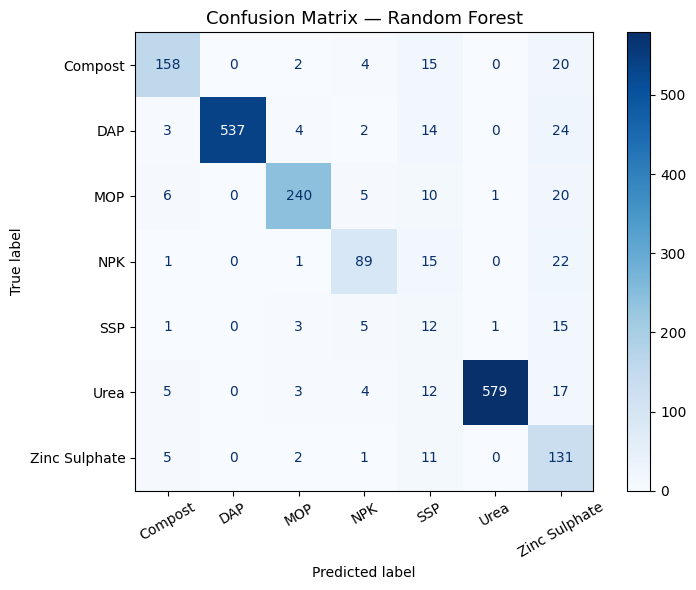

In [8]:
# ── Evaluation ────────────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test_sc)
acc    = accuracy_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred, average='macro')

#support = number of test samples (e.g., for Urea, total count = 3101, so sample = 20% of 3101 = 620)

print(f'Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'Macro F1 Score: {f1:.4f}')
print('\nClassification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=FERTILIZER_CLASSES
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=FERTILIZER_CLASSES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest', fontsize=13)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Stratified 5-Fold Cross-Validation Results:
  Accuracy : 0.8852 ± 0.0072
  F1 Macro : 0.7488  ± 0.0102


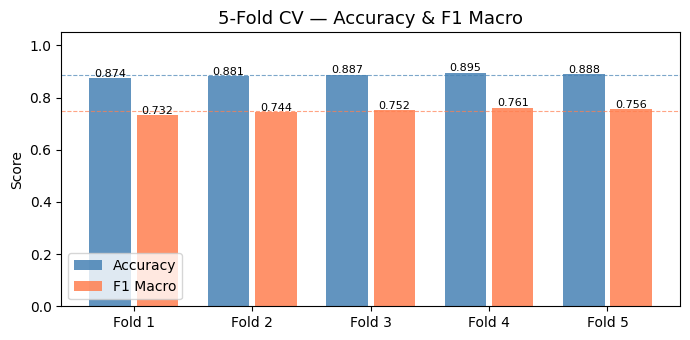

In [9]:
# ── Stratified 5-Fold Cross-Validation ───────────────────────────────────
# Run on original (pre-SMOTE) scaled data to avoid leakage in CV
X_all_sc = scaler.fit_transform(X)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(rf_model, X_all_sc, y, cv=skf, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(rf_model, X_all_sc, y, cv=skf, scoring='f1_macro', n_jobs=-1)

print('Stratified 5-Fold Cross-Validation Results:')
print(f'  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  F1 Macro : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
bars1 = ax.bar(x - 0.2, cv_acc, 0.35, label='Accuracy', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + 0.2, cv_f1,  0.35, label='F1 Macro', color='coral', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('5-Fold CV — Accuracy & F1 Macro', fontsize=13)
ax.legend()
ax.axhline(cv_acc.mean(), color='steelblue', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(cv_f1.mean(),  color='coral',     linestyle='--', linewidth=0.8, alpha=0.7)
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## Section 4 — SHAP Explainability

In [10]:
explainer = shap.TreeExplainer(rf_model)

sample_idx = np.random.RandomState(42).choice(
    len(X_test_sc),
    size=min(500, len(X_test_sc)),
    replace=False
)
X_sample = X_test_sc[sample_idx]

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    mean_abs_shap_per_class = np.array([
        np.abs(sv).mean(axis=0) for sv in shap_values
    ])
    GLOBAL_MEAN_ABS_SHAP = mean_abs_shap_per_class.mean(axis=0)

else:
    GLOBAL_MEAN_ABS_SHAP = np.abs(shap_values).mean(axis=(0, 2))

FEATURE_COLS_ALIGNED = FEATURE_COLS

# ── Create DataFrame safely ───────────────────────────────────
feature_shap_df = pd.DataFrame({
    'feature': FEATURE_COLS_ALIGNED,
    'mean_abs_shap': GLOBAL_MEAN_ABS_SHAP
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(feature_shap_df.head(10))

             feature  mean_abs_shap
0   Phosphorus_Level       0.070069
1     Nitrogen_Level       0.065492
2            Soil_pH       0.047232
3    Potassium_Level       0.046780
4    N_P_interaction       0.033005
5  Crop_Growth_Stage       0.022421
6          NPK_ratio       0.020737
7     Organic_Carbon       0.002933
8    soil_crop_index       0.002893
9    Irrigation_Type       0.002627


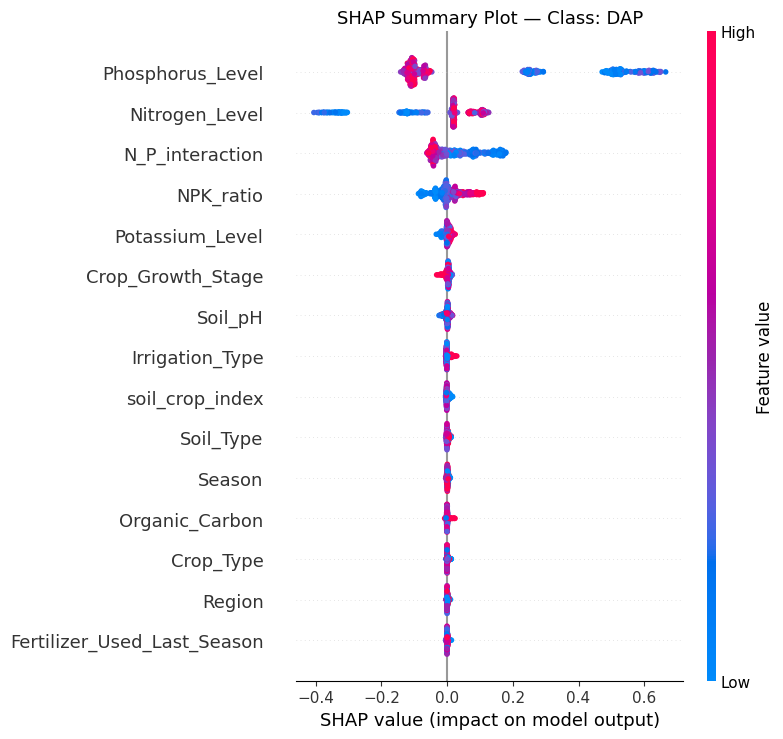

In [11]:
# # Use index of most-predicted class on sample
pred_classes_sample = rf_model.predict(X_sample)
dominant_class_idx  = int(np.bincount(pred_classes_sample).argmax())
dominant_class_name = FERTILIZER_CLASSES[dominant_class_idx]

# ── Determine correct SHAP slice ─────────────────────────────
if isinstance(shap_values, list):
    shap_values_class = shap_values[dominant_class_idx]
else:
    shap_values_class = shap_values[:, :, dominant_class_idx]

# ── Plot ───────────────────────────────────────────────────
shap.summary_plot(
    shap_values_class,
    X_sample,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    max_display=15,
    show=False
)

plt.title(f'SHAP Summary Plot — Class: {dominant_class_name}', fontsize=13)
plt.tight_layout()
plt.show()

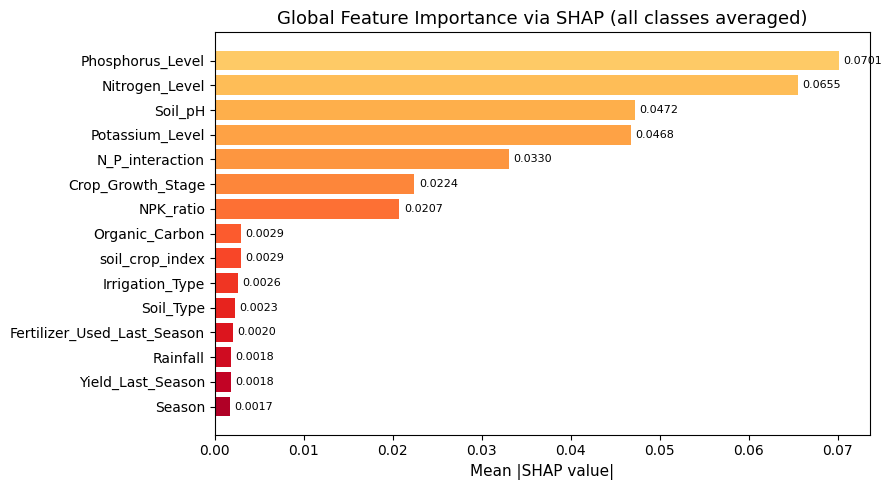

In [12]:
# ── Global Mean |SHAP| Bar Chart ─────────────────────────────────────────
top_n = 15
top_features = feature_shap_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, top_n))[::-1]
bars = ax.barh(top_features['feature'][::-1], top_features['mean_abs_shap'][::-1], color=colors)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Global Feature Importance via SHAP (all classes averaged)', fontsize=13)
for bar, val in zip(bars, top_features['mean_abs_shap'][::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

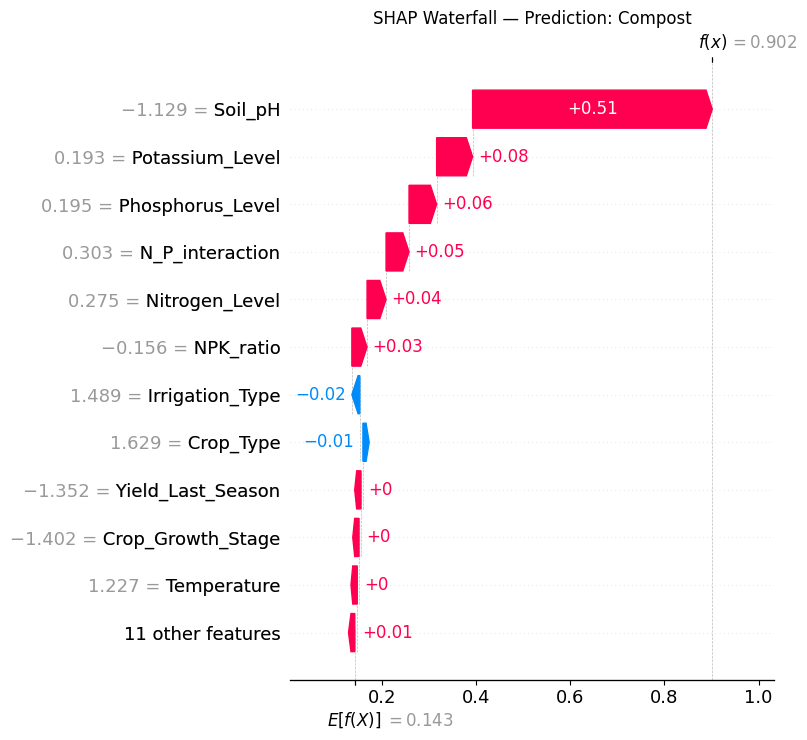

In [15]:
# ── Select instance index to explain ─────────────────────────
INSTANCE_IDX = 0

# ── Predict class for selected instance ─────────────────────
pred_class = rf_model.predict(X_test_sc[[INSTANCE_IDX]])[0]

# ── Get SHAP values for one instance ─────────────────────────
instance_shap = explainer.shap_values(X_test_sc[[INSTANCE_IDX]])
expected_value = explainer.expected_value

# ── Handle SHAP formats correctly ───────────────────────────
if isinstance(instance_shap, list):
    shap_vals = instance_shap[pred_class][0]
else:
    shap_vals = instance_shap[0, :, pred_class]

# ── Fix expected value (CRITICAL FIX) ───────────────────────
if isinstance(expected_value, list):
    ev = expected_value[pred_class]
else:
    ev = expected_value[pred_class] if expected_value.ndim > 0 else expected_value

# Convert to scalar (this fixes your error)
ev = float(np.squeeze(ev))

# ── Build Explanation object ───────────────────────────────
shap_exp = shap.Explanation(
    values=shap_vals,
    base_values=ev,
    data=X_test_sc[INSTANCE_IDX],
    feature_names=FEATURE_COLS
)

# ── Plot ──────────────────────────────────────────────────
shap.waterfall_plot(shap_exp, max_display=12, show=False)

plt.title(
    f'SHAP Waterfall — Prediction: {FERTILIZER_CLASSES[pred_class]}',
    fontsize=12
)
plt.tight_layout()
plt.show()

---
## Section 5 — Fuzzy Weight Mapping

In [16]:
def shap_to_linguistic(norm_shap: float) -> tuple:
    """
    Convert a normalized SHAP score [0,1] to a Triangular Fuzzy Number.
    Returns (l, m, u, label).
    """
    if norm_shap >= 0.75:
        return (0.7, 0.9, 1.0, 'Very High')
    elif norm_shap >= 0.50:
        return (0.5, 0.7, 0.9, 'High')
    elif norm_shap >= 0.25:
        return (0.3, 0.5, 0.7, 'Medium')
    elif norm_shap >= 0.10:
        return (0.1, 0.3, 0.5, 'Low')
    else:
        return (0.0, 0.1, 0.3, 'Very Low')


# ── Normalize global SHAP scores to [0, 1] ───────────────────────────────
shap_min = feature_shap_df['mean_abs_shap'].min()
shap_max = feature_shap_df['mean_abs_shap'].max()
feature_shap_df['norm_shap'] = (
    (feature_shap_df['mean_abs_shap'] - shap_min) /
    (shap_max - shap_min + 1e-10)
)

# Apply mapping
fuzzy_map = feature_shap_df['norm_shap'].apply(shap_to_linguistic)
feature_shap_df['fuzzy_l']    = fuzzy_map.apply(lambda x: x[0])
feature_shap_df['fuzzy_m']    = fuzzy_map.apply(lambda x: x[1])
feature_shap_df['fuzzy_u']    = fuzzy_map.apply(lambda x: x[2])
feature_shap_df['linguistic'] = fuzzy_map.apply(lambda x: x[3])

# Build feature -> TFN lookup
FEATURE_FUZZY_WEIGHTS = {
    row['feature']: (row['fuzzy_l'], row['fuzzy_m'], row['fuzzy_u'])
    for _, row in feature_shap_df.iterrows()
}

print('Fuzzy Weight Mapping (top 12 features):')
print(feature_shap_df[['feature','mean_abs_shap','norm_shap','linguistic','fuzzy_l','fuzzy_m','fuzzy_u']]
      .head(12).to_string(index=False))

Fuzzy Weight Mapping (top 12 features):
                    feature  mean_abs_shap  norm_shap linguistic  fuzzy_l  fuzzy_m  fuzzy_u
           Phosphorus_Level       0.070069   1.000000  Very High      0.7      0.9      1.0
             Nitrogen_Level       0.065492   0.933681  Very High      0.7      0.9      1.0
                    Soil_pH       0.047232   0.669116       High      0.5      0.7      0.9
            Potassium_Level       0.046780   0.662562       High      0.5      0.7      0.9
            N_P_interaction       0.033005   0.462970     Medium      0.3      0.5      0.7
          Crop_Growth_Stage       0.022421   0.309620     Medium      0.3      0.5      0.7
                  NPK_ratio       0.020737   0.285219     Medium      0.3      0.5      0.7
             Organic_Carbon       0.002933   0.027259   Very Low      0.0      0.1      0.3
            soil_crop_index       0.002893   0.026680   Very Low      0.0      0.1      0.3
            Irrigation_Type       0.0026

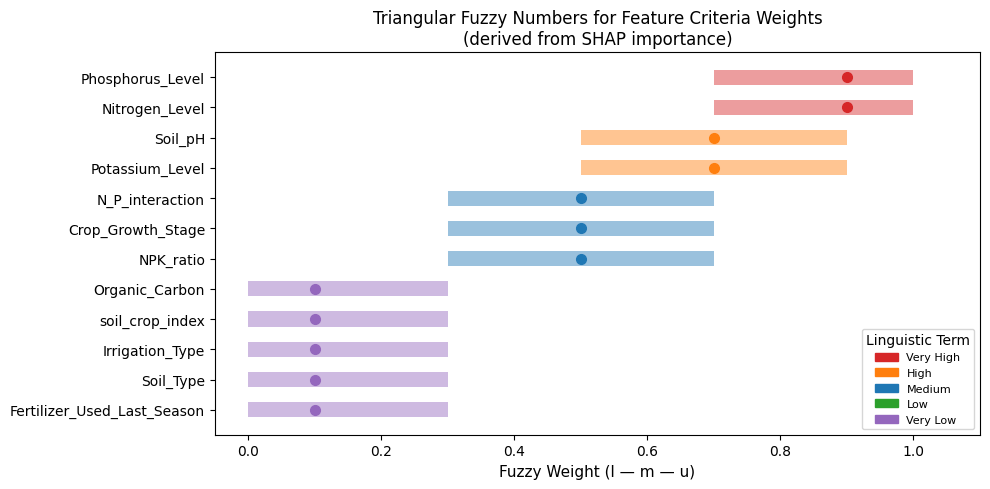

In [17]:
# ── Visualize Fuzzy Weights (error-bar style TFN spread) ─────────────────
top_k_plot = feature_shap_df.head(12)
fig, ax = plt.subplots(figsize=(10, 5))

cmap = {'Very High': '#d62728', 'High': '#ff7f0e',
        'Medium': '#1f77b4', 'Low': '#2ca02c', 'Very Low': '#9467bd'}

for i, row in top_k_plot.iterrows():
    col = cmap.get(row['linguistic'], 'gray')
    ax.barh(row['feature'], row['fuzzy_u'] - row['fuzzy_l'],
            left=row['fuzzy_l'], height=0.5, color=col, alpha=0.45)
    ax.plot([row['fuzzy_m']], [row['feature']], 'o', color=col, markersize=7)

ax.set_xlabel('Fuzzy Weight (l — m — u)', fontsize=11)
ax.set_title('Triangular Fuzzy Numbers for Feature Criteria Weights\n(derived from SHAP importance)', fontsize=12)
ax.set_xlim(-0.05, 1.1)
patches = [mpatches.Patch(color=v, label=k) for k, v in cmap.items()]
ax.legend(handles=patches, title='Linguistic Term', fontsize=8, loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Section 6 — Fuzzy TOPSIS

In [18]:
#  Fuzzy TOPSIS — Core Implementation

# ── Helper: vertex distance between two TFNs ──────────────────
def vertex_distance(a: tuple, b: tuple) -> float:
    #Euclidean distance between two triangular fuzzy numbers.
    return np.sqrt(((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2) / 3)


# ── Helper: normalize a TFN decision column ───────────────────
def normalize_tfn_column(col_values, criterion_type='benefit'):
    #Linear normalization for benefit (maximize) and cost (minimize) criteria.
    #col_values: list of (l, m, u) tuples
    #Returns: list of normalized (l, m, u) tuples

    all_u = [v[2] for v in col_values]
    all_l = [v[0] for v in col_values]

    if criterion_type == 'benefit':
        u_max = max(all_u)
        if u_max == 0: u_max = 1e-10
        return [(l/u_max, m/u_max, u/u_max) for (l, m, u) in col_values]
    else:  # cost
        l_min = min(all_l)
        if l_min == 0: l_min = 1e-10
        return [(l_min/u, l_min/m if m != 0 else 0, l_min/l if l != 0 else 0)
                for (l, m, u) in col_values]


class FuzzyTOPSIS:
    #Fuzzy TOPSIS for multi-criteria ranking of fertilizer alternatives.

    #Parameters
    #----------
    #criteria       : list of str — criterion names
    #criterion_types: list of str — 'benefit' or 'cost' for each criterion
    #criteria_weights: list of (l, m, u) — fuzzy weight per criterion

    def __init__(self, criteria, criterion_types, criteria_weights):
        assert len(criteria) == len(criterion_types) == len(criteria_weights)
        self.criteria         = criteria
        self.criterion_types  = criterion_types
        self.criteria_weights = criteria_weights

    def fit_rank(self, alternatives, decision_matrix):

        # Rank alternatives.

        # Parameters
        # ----------
        # alternatives    : list of str — alternative names
        # decision_matrix : dict {alt: [(l,m,u), ...]}  one tuple per criterion

        # Returns
        # ----------
        # pd.DataFrame with columns [alternative, d_plus, d_minus, cc, rank]

        n_alt = len(alternatives)
        n_cri = len(self.criteria)

        # Step 1 — Build raw decision matrix (n_alt x n_cri) of TFNs
        D = np.empty((n_alt, n_cri), dtype=object)
        for i, alt in enumerate(alternatives):
            for j in range(n_cri):
                D[i, j] = decision_matrix[alt][j]

        # Step 2 — Normalize per column
        D_norm = np.empty_like(D)
        for j in range(n_cri):
            col = [D[i, j] for i in range(n_alt)]
            normed = normalize_tfn_column(col, self.criterion_types[j])
            for i in range(n_alt):
                D_norm[i, j] = normed[i]

        # Step 3 — Apply fuzzy weights: V = D_norm * W  (TFN multiplication)
        V = np.empty_like(D_norm)
        for i in range(n_alt):
            for j in range(n_cri):
                r = D_norm[i, j]
                w = self.criteria_weights[j]
                V[i, j] = (r[0]*w[0], r[1]*w[1], r[2]*w[2])

        # Step 4 — FPIS (best) and FNIS (worst) per column
        FPIS = [(1.0, 1.0, 1.0)] * n_cri   # ideal positive
        FNIS = [(0.0, 0.0, 0.0)] * n_cri   # ideal negative

        # Step 5 — Distance from FPIS (d+) and FNIS (d-)
        d_plus  = np.zeros(n_alt)
        d_minus = np.zeros(n_alt)
        for i in range(n_alt):
            d_plus[i]  = sum(vertex_distance(V[i, j], FPIS[j]) for j in range(n_cri))
            d_minus[i] = sum(vertex_distance(V[i, j], FNIS[j]) for j in range(n_cri))

        # Step 6 — Closeness Coefficient
        cc = d_minus / (d_plus + d_minus + 1e-10)

        result = pd.DataFrame({
            'Alternative': alternatives,
            'd_plus' : d_plus,
            'd_minus': d_minus,
            'CC'     : cc
        })
        result['Rank'] = result['CC'].rank(ascending=False).astype(int)
        result = result.sort_values('CC', ascending=False).reset_index(drop=True)
        return result


print('FuzzyTOPSIS class defined successfully.')

FuzzyTOPSIS class defined successfully.


In [19]:
#  Define criteria and agronomic decision matrix
#  Each fertilizer is rated on each criterion using domain knowledge

CRITERIA       = ['Nutrient Efficiency', 'Cost Effectiveness', 'Environmental Impact', 'Soil pH Suitability', 'Crop Compatibility']
CRITERION_TYPES = ['benefit',            'cost',              'cost',                 'benefit',             'benefit']

shap_lookup = {row['feature']: (row['fuzzy_l'], row['fuzzy_m'], row['fuzzy_u'])
               for _, row in feature_shap_df.iterrows()}

def get_weight(feature_name, fallback=(0.3, 0.5, 0.7)):
    return shap_lookup.get(feature_name, fallback)

CRITERIA_WEIGHTS = [
    get_weight('Nitrogen_Level'),       # Nutrient Efficiency (proxy: N SHAP importance)
    get_weight('Fertilizer_Used_Last_Season'),  # Cost Effectiveness
    get_weight('Electrical_Conductivity'),       # Environmental Impact
    get_weight('Soil_pH'),              # Soil pH Suitability
    get_weight('Crop_Type'),            # Crop Compatibility
]

print('Criteria weights (TFNs from SHAP):')
for crit, weight in zip(CRITERIA, CRITERIA_WEIGHTS):
    print(f'  {crit:<25}: {weight}')


AGRONOMIC_RATINGS = {
    #                 Nutrient Eff.      Cost Eff.           Env. Impact          pH Suitability      Crop Compat.
    'Urea'        : [(0.7, 0.9, 1.0),  (0.7, 0.9, 1.0),  (0.3, 0.5, 0.7),  (0.5, 0.7, 0.9),  (0.7, 0.9, 1.0)],
    'DAP'         : [(0.6, 0.8, 0.9),  (0.5, 0.7, 0.9),  (0.3, 0.5, 0.7),  (0.6, 0.8, 0.9),  (0.6, 0.8, 0.9)],
    'MOP'         : [(0.5, 0.7, 0.8),  (0.5, 0.7, 0.8),  (0.4, 0.6, 0.8),  (0.5, 0.7, 0.8),  (0.5, 0.7, 0.8)],
    'Compost'     : [(0.3, 0.5, 0.7),  (0.7, 0.9, 1.0),  (0.7, 0.9, 1.0),  (0.6, 0.8, 0.9),  (0.5, 0.7, 0.9)],
    'Zinc Sulphate': [(0.4, 0.6, 0.8), (0.3, 0.5, 0.7),  (0.3, 0.5, 0.7),  (0.4, 0.6, 0.8),  (0.4, 0.6, 0.7)],
    'NPK'         : [(0.6, 0.8, 1.0),  (0.4, 0.6, 0.8),  (0.3, 0.5, 0.7),  (0.5, 0.7, 0.9),  (0.6, 0.8, 1.0)],
    'SSP'         : [(0.4, 0.6, 0.8),  (0.6, 0.8, 0.9),  (0.4, 0.6, 0.8),  (0.4, 0.6, 0.8),  (0.4, 0.6, 0.8)],
}

print('\nAgronomic decision matrix defined for all 7 fertilizer classes.')

Criteria weights (TFNs from SHAP):
  Nutrient Efficiency      : (0.7, 0.9, 1.0)
  Cost Effectiveness       : (0.0, 0.1, 0.3)
  Environmental Impact     : (0.0, 0.1, 0.3)
  Soil pH Suitability      : (0.5, 0.7, 0.9)
  Crop Compatibility       : (0.0, 0.1, 0.3)

Agronomic decision matrix defined for all 7 fertilizer classes.


In [20]:
# ── Run Fuzzy TOPSIS on all 7 alternatives ────────────────────────────────
ft = FuzzyTOPSIS(
    criteria        = CRITERIA,
    criterion_types = CRITERION_TYPES,
    criteria_weights= CRITERIA_WEIGHTS
)

all_alternatives = list(AGRONOMIC_RATINGS.keys())
results_all = ft.fit_rank(all_alternatives, AGRONOMIC_RATINGS)

print('=== Fuzzy TOPSIS Ranking (all 7 fertilizers) ===')
print(results_all.to_string(index=False))

=== Fuzzy TOPSIS Ranking (all 7 fertilizers) ===
  Alternative   d_plus  d_minus       CC  Rank
         Urea 3.526711 1.857291 0.344965     1
          NPK 3.553640 1.868700 0.344630     2
          DAP 3.531400 1.814655 0.339438     3
          MOP 3.697974 1.587160 0.300307     4
Zinc Sulphate 3.756479 1.609493 0.299944     5
          SSP 3.822079 1.495296 0.281209     6
      Compost 3.817492 1.470293 0.278055     7


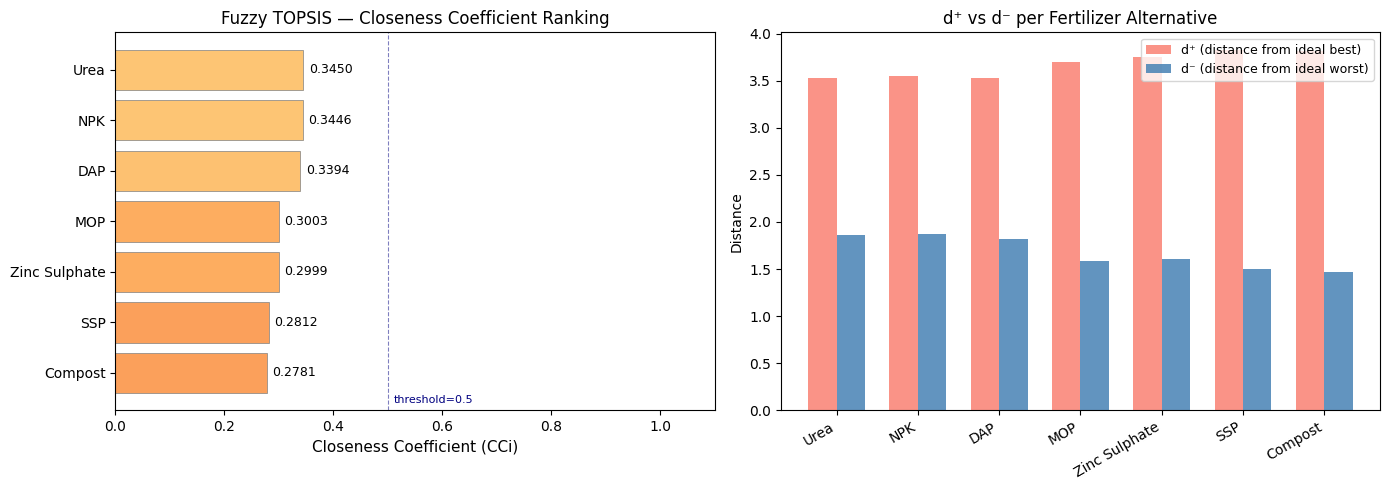

In [21]:
# ── Visualization: CC scores + d+/d- bars ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Closeness Coefficient
colors_cc = plt.cm.RdYlGn(results_all['CC'].values)
bars = axes[0].barh(results_all['Alternative'], results_all['CC'], color=colors_cc, edgecolor='gray', linewidth=0.5)
axes[0].set_xlabel('Closeness Coefficient (CCi)', fontsize=11)
axes[0].set_title('Fuzzy TOPSIS — Closeness Coefficient Ranking', fontsize=12)
axes[0].set_xlim(0, 1.1)
for bar, cc_val in zip(bars, results_all['CC']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{cc_val:.4f}', va='center', fontsize=9)
axes[0].invert_yaxis()
axes[0].axvline(0.5, color='navy', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].text(0.51, 0.02, 'threshold=0.5', fontsize=8, color='navy', transform=axes[0].get_xaxis_transform())

# Right: d+ vs d- comparison
x_pos = np.arange(len(results_all))
w = 0.35
axes[1].bar(x_pos - w/2, results_all['d_plus'],  w, label='d⁺ (distance from ideal best)', color='salmon', alpha=0.85)
axes[1].bar(x_pos + w/2, results_all['d_minus'], w, label='d⁻ (distance from ideal worst)', color='steelblue', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(results_all['Alternative'], rotation=30, ha='right')
axes[1].set_ylabel('Distance')
axes[1].set_title('d⁺ vs d⁻ per Fertilizer Alternative', fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 7 — Hybrid Inference Pipeline

In [22]:
def preprocess_sample(sample_dict):
    row = pd.DataFrame([sample_dict])

    for col, le in label_encoders.items():
        if col in row.columns:
            row[col] = le.transform(row[col])

    row['NPK_ratio']       = row['Nitrogen_Level'] / (row['Phosphorus_Level'] + row['Potassium_Level'] + 1e-6)
    row['N_P_interaction'] = row['Nitrogen_Level'] * row['Phosphorus_Level']
    row['soil_crop_index'] = row['Soil_Type'] * row['Crop_Type']

    X_raw = row[FEATURE_COLS].values
    X_sc  = scaler.transform(X_raw)
    return X_sc


def hybrid_recommend(sample_dict, top_k=3, verbose=True):

    # ── Step 1 ─────────────────────────────
    X_sc = preprocess_sample(sample_dict)

    # ── Step 2 ─────────────────────────────
    proba     = rf_model.predict_proba(X_sc)[0]
    pred_idx  = np.argmax(proba)
    rf_pred   = FERTILIZER_CLASSES[pred_idx]

    prob_df = pd.DataFrame({
        'Fertilizer': FERTILIZER_CLASSES,
        'Probability': proba
    }).sort_values('Probability', ascending=False)

    top_candidates = prob_df.head(top_k)['Fertilizer'].tolist()

    if verbose:
        print("="*60)
        print("STEP 1 — RF Prediction")
        print("="*60)
        print(prob_df)

    # ── Step 3: SHAP (FIXED FINAL) ────────────────────────
    inst_shap = explainer.shap_values(X_sc)

    if isinstance(inst_shap, list):
        shap_vals = inst_shap[pred_idx]
    else:
        shap_vals = inst_shap

    shap_vals = np.array(shap_vals).reshape(-1)

    n_feat = min(len(FEATURE_COLS), len(shap_vals))

    shap_contrib = pd.DataFrame({
        'Feature': FEATURE_COLS[:n_feat],
        'SHAP Value': shap_vals[:n_feat],
        'Abs SHAP': np.abs(shap_vals[:n_feat])
    }).sort_values('Abs SHAP', ascending=False)

    top_drivers = shap_contrib.head(5)

    if verbose:
        print("\n" + "="*60)
        print("STEP 2 — SHAP Drivers")
        print("="*60)
        print(top_drivers)

    # ── Step 4 ─────────────────────────────
    candidate_matrix = {
        k: AGRONOMIC_RATINGS[k]
        for k in top_candidates
        if k in AGRONOMIC_RATINGS
    }

    ft_result = ft.fit_rank(list(candidate_matrix.keys()), candidate_matrix)

    if verbose:
        print("\n" + "="*60)
        print("STEP 3 — TOPSIS")
        print("="*60)
        print(ft_result)

    return {
        'rf_prediction': rf_pred,
        'rf_probabilities': prob_df,
        'shap_top_drivers': shap_contrib,
        'fuzzy_topsis_ranking': ft_result,
        'final_recommendation': ft_result.iloc[0]['Alternative'],
        'final_cc': ft_result.iloc[0]['CC']
    }

In [23]:
# ── Run on a sample input ─────────────────────────────────────────────────
SAMPLE_INPUT = {
    'Soil_Type'                  : 'Clay',
    'Soil_pH'                    : 5.8,
    'Soil_Moisture'              : 42.0,
    'Organic_Carbon'             : 1.2,
    'Electrical_Conductivity'    : 0.35,
    'Nitrogen_Level'             : 28,
    'Phosphorus_Level'           : 18,
    'Potassium_Level'            : 120,
    'Temperature'                : 31.0,
    'Humidity'                   : 72.0,
    'Rainfall'                   : 850.0,
    'Crop_Type'                  : 'Rice',
    'Crop_Growth_Stage'          : 'Sowing',
    'Season'                     : 'Kharif',
    'Irrigation_Type'            : 'Canal',
    'Previous_Crop'              : 'Wheat',
    'Region'                     : 'East',
    'Fertilizer_Used_Last_Season': 55.0,
    'Yield_Last_Season'          : 3.8
}

result = hybrid_recommend(SAMPLE_INPUT, top_k=3, verbose=True)

STEP 1 — RF Prediction
      Fertilizer  Probability
5           Urea     0.949861
1            DAP     0.041806
4            SSP     0.005000
3            NPK     0.002667
6  Zinc Sulphate     0.000667
2            MOP     0.000000
0        Compost     0.000000

STEP 2 — SHAP Drivers
            Feature  SHAP Value  Abs SHAP
7   Potassium_Level   -0.023591  0.023591
11        Crop_Type    0.021052  0.021052
13           Season   -0.020951  0.020951
10         Rainfall    0.017997  0.017997
5    Nitrogen_Level   -0.005848  0.005848

STEP 3 — TOPSIS
  Alternative    d_plus   d_minus        CC  Rank
0        Urea  3.493683  1.908415  0.353273     1
1         DAP  3.487992  1.885874  0.350934     2
2         SSP  3.784525  1.554808  0.291199     3


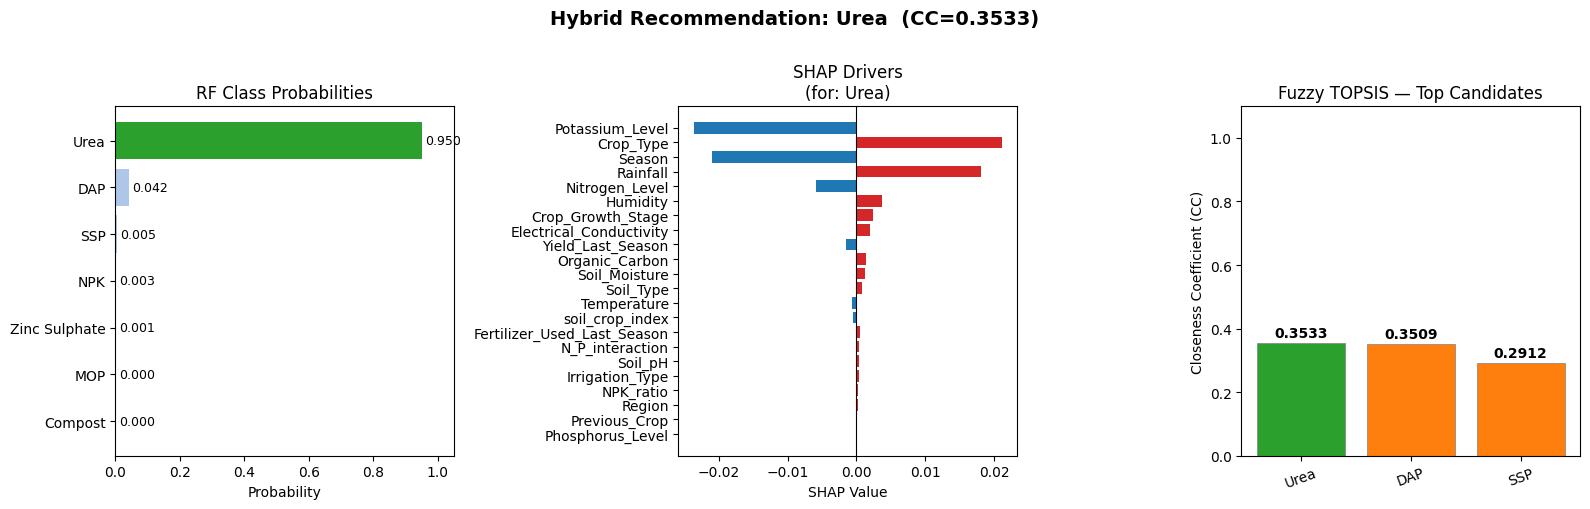

In [24]:
# ── Visualize inference result ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. RF probabilities
prob_df = result['rf_probabilities']
colors_p = ['#2ca02c' if f == result['final_recommendation'] else '#aec7e8'
            for f in prob_df['Fertilizer']]
axes[0].barh(prob_df['Fertilizer'][::-1], prob_df['Probability'][::-1], color=colors_p[::-1])
axes[0].set_xlabel('Probability')
axes[0].set_title('RF Class Probabilities', fontsize=12)
axes[0].set_xlim(0, 1.05)
for i, (fert, prob) in enumerate(zip(prob_df['Fertilizer'][::-1], prob_df['Probability'][::-1])):
    axes[0].text(prob + 0.01, i, f'{prob:.3f}', va='center', fontsize=9)

# 2. SHAP top drivers
shap_top = result['shap_top_drivers']
colors_s = ['#d62728' if v > 0 else '#1f77b4' for v in shap_top['SHAP Value']]
axes[1].barh(shap_top['Feature'][::-1], shap_top['SHAP Value'][::-1], color=colors_s[::-1])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('SHAP Value')
axes[1].set_title(f'SHAP Drivers\n(for: {result["rf_prediction"]})', fontsize=12)

# 3. Fuzzy TOPSIS CC scores
ft_res = result['fuzzy_topsis_ranking']
colors_ft = ['#2ca02c' if a == result['final_recommendation'] else '#ff7f0e'
             for a in ft_res['Alternative']]
axes[2].bar(ft_res['Alternative'], ft_res['CC'], color=colors_ft, edgecolor='gray', linewidth=0.5)
axes[2].set_ylabel('Closeness Coefficient (CC)')
axes[2].set_title('Fuzzy TOPSIS — Top Candidates', fontsize=12)
axes[2].set_ylim(0, 1.1)
for i, (alt, cc) in enumerate(zip(ft_res['Alternative'], ft_res['CC'])):
    axes[2].text(i, cc + 0.02, f'{cc:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle(
    f'Hybrid Recommendation: {result["final_recommendation"]}  (CC={result["final_cc"]:.4f})',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

---
## Section 8 — Natural Language Explanation Generator

In [25]:
# ── Agronomic description bank ────────────────────────────────────────────
FERTILIZER_DESCRIPTIONS = {
    'Urea'        : 'a high-nitrogen fertilizer (46% N) ideal for nitrogen-deficient soils and fast-growing crops',
    'DAP'         : 'a diammonium phosphate fertilizer rich in both nitrogen (18%) and phosphorus (46%), promoting root development',
    'MOP'         : 'muriate of potash, a high-potassium fertilizer (60% K₂O) that strengthens plant stems and disease resistance',
    'Compost'     : 'an organic slow-release fertilizer that improves soil structure, water retention, and microbial activity',
    'Zinc Sulphate': 'a micronutrient fertilizer that corrects zinc deficiency, important for enzyme function and grain filling',
    'NPK'         : 'a balanced compound fertilizer providing all three macronutrients (nitrogen, phosphorus, potassium) in one application',
    'SSP'         : 'single superphosphate, a phosphorus-rich fertilizer (16% P₂O₅) that also supplies calcium and sulfur',
}

DRIVER_DESCRIPTIONS = {
    'Nitrogen_Level'           : 'soil nitrogen level',
    'Phosphorus_Level'         : 'soil phosphorus level',
    'Potassium_Level'          : 'soil potassium level',
    'Soil_pH'                  : 'soil pH',
    'Soil_Moisture'            : 'soil moisture content',
    'Organic_Carbon'           : 'organic carbon content',
    'Electrical_Conductivity'  : 'soil electrical conductivity',
    'Crop_Type'                : 'crop type',
    'Season'                   : 'growing season',
    'Rainfall'                 : 'rainfall level',
    'Temperature'              : 'temperature',
    'Irrigation_Type'          : 'irrigation method',
    'Yield_Last_Season'        : 'last season yield',
    'NPK_ratio'                : 'NPK balance ratio',
    'N_P_interaction'          : 'nitrogen-phosphorus interaction',
    'soil_crop_index'          : 'soil-crop compatibility index',
}


def generate_explanation(result_dict, sample_dict):
    """
    Generate a structured natural language explanation from the hybrid result.
    """
    rec      = result_dict['final_recommendation']
    cc       = result_dict['final_cc']
    rf_pred  = result_dict['rf_prediction']
    rf_proba = result_dict['rf_probabilities']
    drivers  = result_dict['shap_top_drivers']
    ft_rank  = result_dict['fuzzy_topsis_ranking']

    # RF confidence for top prediction
    rf_conf  = rf_proba[rf_proba['Fertilizer'] == rf_pred]['Probability'].values[0]

    # Top 3 positive drivers
    pos_drivers = drivers[drivers['SHAP Value'] > 0].head(3)
    neg_drivers = drivers[drivers['SHAP Value'] < 0].head(2)

    # Format feature values from sample
    def fmt_feature(feat_name):
        display = DRIVER_DESCRIPTIONS.get(feat_name, feat_name)
        raw_val = sample_dict.get(feat_name, '?')
        return f"{display} ({raw_val})"

    # ── Build explanation sections ─────────────────────────────────────────
    lines = []
    lines.append('=' * 65)
    lines.append('  FERTILIZER RECOMMENDATION REPORT')
    lines.append('=' * 65)

    lines.append(f'\n RECOMMENDATION : {rec}')
    desc = FERTILIZER_DESCRIPTIONS.get(rec, '')
    if desc:
        lines.append(f'  ({rec} is {desc})')

    lines.append(f'\n CONFIDENCE')
    lines.append(f'  - ML model probability  : {rf_conf*100:.1f}%')
    lines.append(f'  - Multi-criteria score  : {cc:.4f} / 1.0000')
    lines.append(f'    (Fuzzy TOPSIS closeness coefficient)')

    lines.append(f'\n WHY {rec.upper()}?  (Key factors from SHAP analysis)')
    if not pos_drivers.empty:
        lines.append('  Factors pushing towards this recommendation:')
        for _, row in pos_drivers.iterrows():
            lines.append(f'    + {fmt_feature(row["Feature"])}  [SHAP: +{row["SHAP Value"]:.4f}]')
    if not neg_drivers.empty:
        lines.append('  Factors pulling away (but overridden):')
        for _, row in neg_drivers.iterrows():
            lines.append(f'    - {fmt_feature(row["Feature"])}  [SHAP: {row["SHAP Value"]:.4f}]')

    lines.append(f'\n MULTI-CRITERIA RANKING  (Fuzzy TOPSIS)')
    for _, row in ft_rank.iterrows():
        marker = ' <<< SELECTED' if row['Alternative'] == rec else ''
        lines.append(f'  Rank {row["Rank"]}. {row["Alternative"]:<20} CC = {row["CC"]:.4f}{marker}')

    lines.append(f'\n FIELD CONTEXT')
    lines.append(f'  Crop     : {sample_dict.get("Crop_Type", "?")} | Season: {sample_dict.get("Season", "?")} | Region: {sample_dict.get("Region", "?")}  ')
    lines.append(f'  Soil     : {sample_dict.get("Soil_Type", "?")} | pH: {sample_dict.get("Soil_pH", "?")} | N={sample_dict.get("Nitrogen_Level","?")} P={sample_dict.get("Phosphorus_Level","?")} K={sample_dict.get("Potassium_Level","?")}  ')
    lines.append(f'  Irrigation: {sample_dict.get("Irrigation_Type", "?")} | Rainfall: {sample_dict.get("Rainfall", "?")} mm')

    lines.append('\n' + '=' * 65)

    explanation = '\n'.join(lines)
    print(explanation)
    return explanation


explanation_text = generate_explanation(result, SAMPLE_INPUT)

  FERTILIZER RECOMMENDATION REPORT

 RECOMMENDATION : Urea
  (Urea is a high-nitrogen fertilizer (46% N) ideal for nitrogen-deficient soils and fast-growing crops)

 CONFIDENCE
  - ML model probability  : 95.0%
  - Multi-criteria score  : 0.3533 / 1.0000
    (Fuzzy TOPSIS closeness coefficient)

 WHY UREA?  (Key factors from SHAP analysis)
  Factors pushing towards this recommendation:
    + crop type (Rice)  [SHAP: +0.0211]
    + rainfall level (850.0)  [SHAP: +0.0180]
    + Humidity (72.0)  [SHAP: +0.0038]
  Factors pulling away (but overridden):
    - soil potassium level (120)  [SHAP: -0.0236]
    - growing season (Kharif)  [SHAP: -0.0210]

 MULTI-CRITERIA RANKING  (Fuzzy TOPSIS)
  Rank 1. Urea                 CC = 0.3533 <<< SELECTED
  Rank 2. DAP                  CC = 0.3509
  Rank 3. SSP                  CC = 0.2912

 FIELD CONTEXT
  Crop     : Rice | Season: Kharif | Region: East  
  Soil     : Clay | pH: 5.8 | N=28 P=18 K=120  
  Irrigation: Canal | Rainfall: 850.0 mm

